# Imports

In [4]:
import numpy as np
import pandas as pd

from pyFiberPhotometry import SimulatedPhotometryGenerator
from pyFiberPhotometry import PhotometryExperiment, PhotometryData

# Build Simulated data

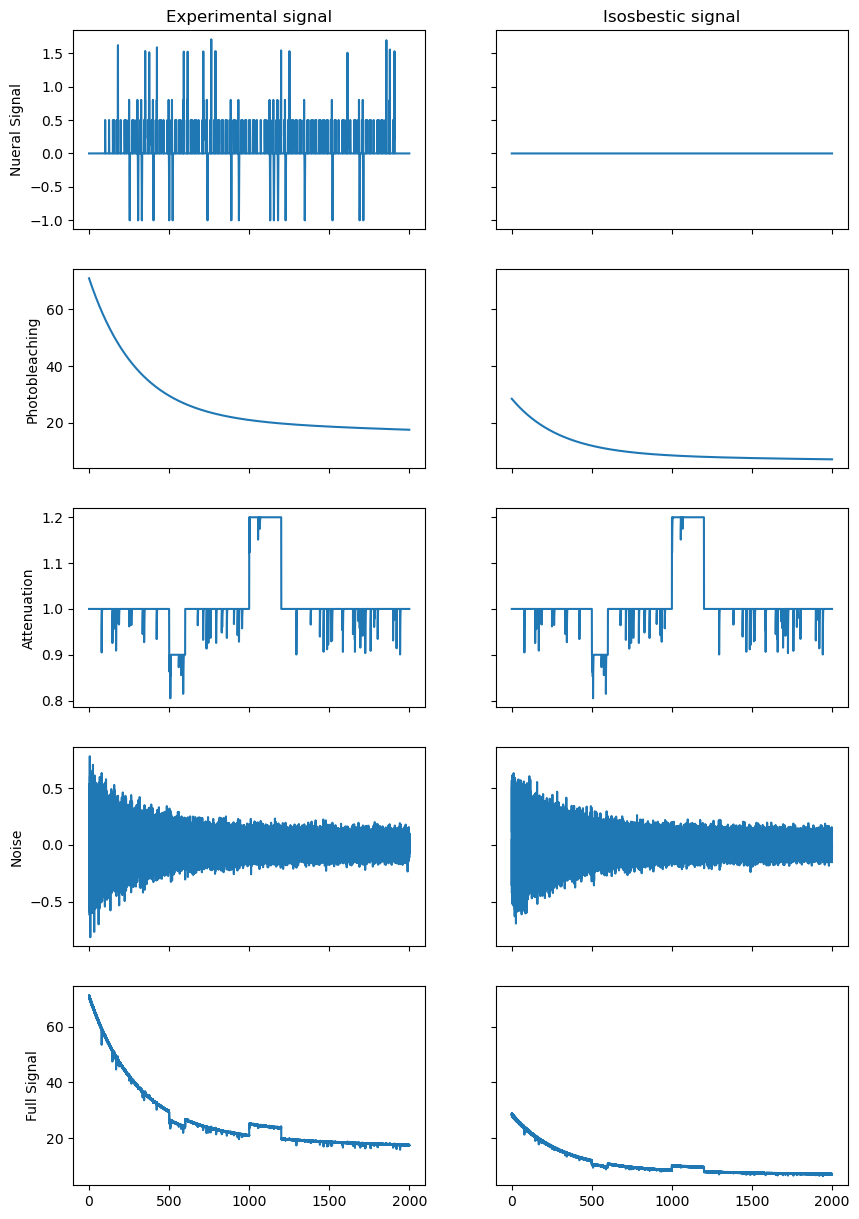

In [5]:
T_sec = 2000
fs = 100
N = T_sec * fs

bleach_params = dict(a1=50, a2=20, tau1=300, tau2=10000, b0=1)

artifact_mask = np.ones(shape=N)
unit_idx = N // 20
artifact_mask[10*unit_idx : 12*unit_idx] += 0.2
artifact_mask[5*unit_idx : 6*unit_idx] -= 0.1

sim = SimulatedPhotometryGenerator(
    T_sec=T_sec,
    fs=fs,
    n_events=75,
    A_neural=0.5,
    buffer_sec=100,
    tau_p_sec=0.2,
    bleach_params=bleach_params,
    bleach_iso_scale=0.4,
    dependent_sigma_exp=2e-1,
    dependent_sigma_iso=2e-1,
    independent_sigma_exp=5e-5,
    independent_sigma_iso=5e-5,
    seed=43546,
    event_dur_sec=2,
    artifact_depth_range=(0.02, 0.10),
    artifact_mask=artifact_mask,
)

sim.add_event(
    relative_to='event',
    time_range=(3, 8),
    overall_prob=0.8,
    choices=['lever1', 'lever2'],
    choice_probs=[0.6, 0.4],
    peak_specs={
        'lever1' : {'amplitude':0.5, 'event_dur_sec':4, 'tau_p_sec':3, 'shape_k':5},
        'lever2' : {'amplitude':0.8, 'event_dur_sec':3, 'tau_p_sec':0.2, 'shape_k':4},
    }
)

sim.add_event(
    relative_to='lever2',
    time_range=(1, 2),
    overall_prob=1.0,
    choices=['loud_noise', 'no_loud_noise'],
    choice_probs=[0.5, 0.5],
    peak_specs={
        'no_loud_noise' : {'amplitude':1.5, 'event_dur_sec':1, 'tau_p_sec':1, 'shape_k':2},
        'loud_noise' : {'amplitude':-1.0, 'event_dur_sec':5, 'tau_p_sec':3, 'shape_k':5},
    }
)

sim.plot_layers()

# Exercises

## Task 1
1. Preprocess the signal with dF/F, IRLS, and a cutoff frequency of 5 Hz.
2. Then extract the trial data and set ``tr = exp.trial_data``

In [6]:
# setup
exp = sim.to_PhotometryExperiment(downsample=1)

# solve

# solution
exp.preprocess_signal(
    cutoff_frequency=5,
    order=4,
    correction_method='dF/F',
    signal_normalization='none',
    fit_using='IRLS',
    maxiter=200,
    c=1.4,
)

exp.extract_trial_data(
    align_to='event',
    center_on=['lever1', 'lever2'],
    trial_bounds=(-10, 10),
    event_tolerences={
        'lever1':(2, 10),
        'lever2':(2, 10),
        'loud_noise':(4, 12),
    },
    trial_normalization='none',
    event_conflict_logic='first',
)

tr = exp.trial_data

## Task 2
1. Label the trials in tr.obs according to the following:
    - If 'lever1' and 'lever2' are missing, label = 'no_response'
    - If 'lever1', label = 'type1'
    - If 'lever2' and 'loud_noise' is missing, label = 'type2'
    - If 'lever2' and 'loud_noise', label = 'type3'

Hint: remeber an NaN value represents a missing event.

In [7]:
# solve

# solution
has_l1 = ~tr.obs['lever1'].isna()
has_l2 = ~tr.obs['lever2'].isna()
has_ln = ~tr.obs['loud_noise'].isna()

tr.obs['trial_label'] = pd.NA
tr.obs.loc[has_l1, 'trial_label'] = 'type1'
tr.obs.loc[has_l2 & ~has_ln, 'trial_label'] = 'type2'
tr.obs.loc[has_l2 & has_ln, 'trial_label'] = 'type3'
tr.obs.loc[~has_l1 & ~has_l2, 'trial_label'] = 'NoResponse'

tr.obs

,event,lever1,lever2,loud_noise,trial_label
0,0.000000,NaN,NaN,NaN,NoResponse
1,0.000000,NaN,NaN,NaN,NoResponse
2,-5.613315,0.0,NaN,NaN,type1
3,-5.984555,NaN,0.0,NaN,type2
4,0.000000,NaN,NaN,NaN,NoResponse
...,...,...,...,...,...
70,-6.541957,0.0,NaN,NaN,type1
71,-5.814808,0.0,NaN,NaN,type1
72,-5.952285,NaN,0.0,NaN,type2
73,-3.173764,NaN,0.0,NaN,type2


## Task 3
1. Filter out 'NoResponse' trials
2. Average trials of the same type
3. Plot the trials on the same graph with error bars and labels

/Users/ggolde/home/dev/pyFiberPhotometry/pyFiberPhotometry/core/PhotometeryData.py:244: RuntimeWarning: Mean of empty slice
  obs_agg.loc[i, data_cols] = method(obs.iloc[idxs][data_cols], axis=0)
/Users/ggolde/home/dev/pyFiberPhotometry/pyFiberPhotometry/core/PhotometeryData.py:244: RuntimeWarning: Mean of empty slice
  obs_agg.loc[i, data_cols] = method(obs.iloc[idxs][data_cols], axis=0)


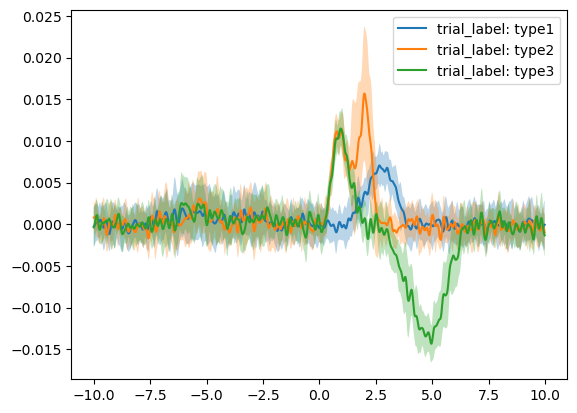

In [8]:
# solve

# solution
tr.filter_rows(tr.obs['trial_label'] != 'NoResponse', inplace=True)

avg = tr.collapse(
    group_on=['trial_label'],
    data_cols=['event', 'loud_noise'],
)

avg.plot_all(label_with=['trial_label'], err_layer='std')